In [1]:
# Dataset: UCI Heart Disease (Cleveland subset)
# Goal: Binary classification (0 = no disease, 1 = disease present)


 SECTION 1: IMPORTS AND DATA LOADING

In [2]:

# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve, classification_report
)

# Imbalanced learning
from imblearn.over_sampling import SMOTE

# SHAP for explainability
import shap

# Dataset fetching
from ucimlrepo import fetch_ucirepo

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('All libraries imported successfully!')

# Fetch the Heart Disease dataset
print('\\nFetching UCI Heart Disease dataset...')
heart_disease = fetch_ucirepo(id=45)

# Filter to Cleveland subset only (first 303 records)
cleveland_mask = heart_disease.data.features.index < 303
X = heart_disease.data.features[cleveland_mask].copy()
y = heart_disease.data.targets[cleveland_mask].copy()

# Binarize target: 0 = no disease, 1+ = disease present
y = (y['num'] > 0).astype(int).values.ravel()

print(f'\\nDataset loaded successfully!')
print(f'X shape: {X.shape}')
print(f'\\nFirst 5 rows:')
print(X.head())

print(f'\\nData types:')
print(X.dtypes)
print(f'\\nTarget distribution:')
print(pd.Series(y).value_counts())
print(f'\\nConfirming 13 feature columns:')
print(f'Columns present: {list(X.columns)}')
print(f'Number of features: {len(X.columns)}')


All libraries imported successfully!
\nFetching UCI Heart Disease dataset...
\nDataset loaded successfully!
X shape: (303, 13)
\nFirst 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  
\nData types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype:

## SECTION 2: MISSING VALUE HANDLING

In [3]:

print('\\n' + '='*80)
print('SECTION 2: MISSING VALUE HANDLING')
print('='*80)

# Print missing value count per column
print('\\nMissing values per column:')
print(X.isnull().sum())

# Impute missing values
# For 'ca' and 'thal': use MODE (most frequent value) - they are categorical
# For other numeric columns: use MEDIAN - more robust to outliers in medical data

for col in X.columns:
    if X[col].isnull().sum() > 0:
        if col in ['ca', 'thal']:
            # Categorical - use mode
            mode_value = X[col].mode()[0]
            X[col] = X[col].fillna(mode_value)
            print(f'Imputed {col} with MODE: {mode_value}')
        else:
            # Numeric - use median
            median_value = X[col].median()
            X[col] = X[col].fillna(median_value)
            print(f'Imputed {col} with MEDIAN: {median_value}')

# Convert all columns to float type
X = X.astype(float)

# Confirm zero missing values
print(f'\\nMissing values after imputation:')
print(X.isnull().sum().sum())
print('✓ All missing values handled successfully!')


\n================================================================================
SECTION 2: MISSING VALUE HANDLING
\nMissing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64
Imputed ca with MODE: 0.0
Imputed thal with MODE: 3.0
\nMissing values after imputation:
0
✓ All missing values handled successfully!


## SECTION 3: EXPLORATORY DATA ANALYSIS

\n================================================================================
SECTION 3: EXPLORATORY DATA ANALYSIS


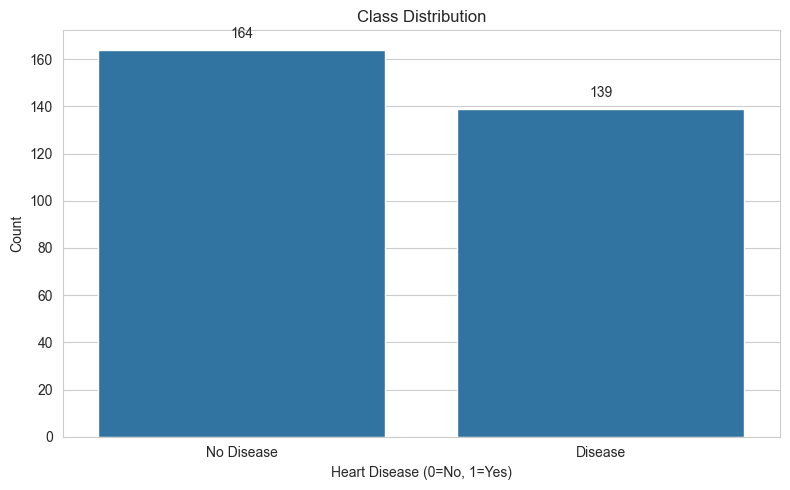

\nClass Balance:
No Disease (0): 164 (54.1%)
Disease (1): 139 (45.9%)


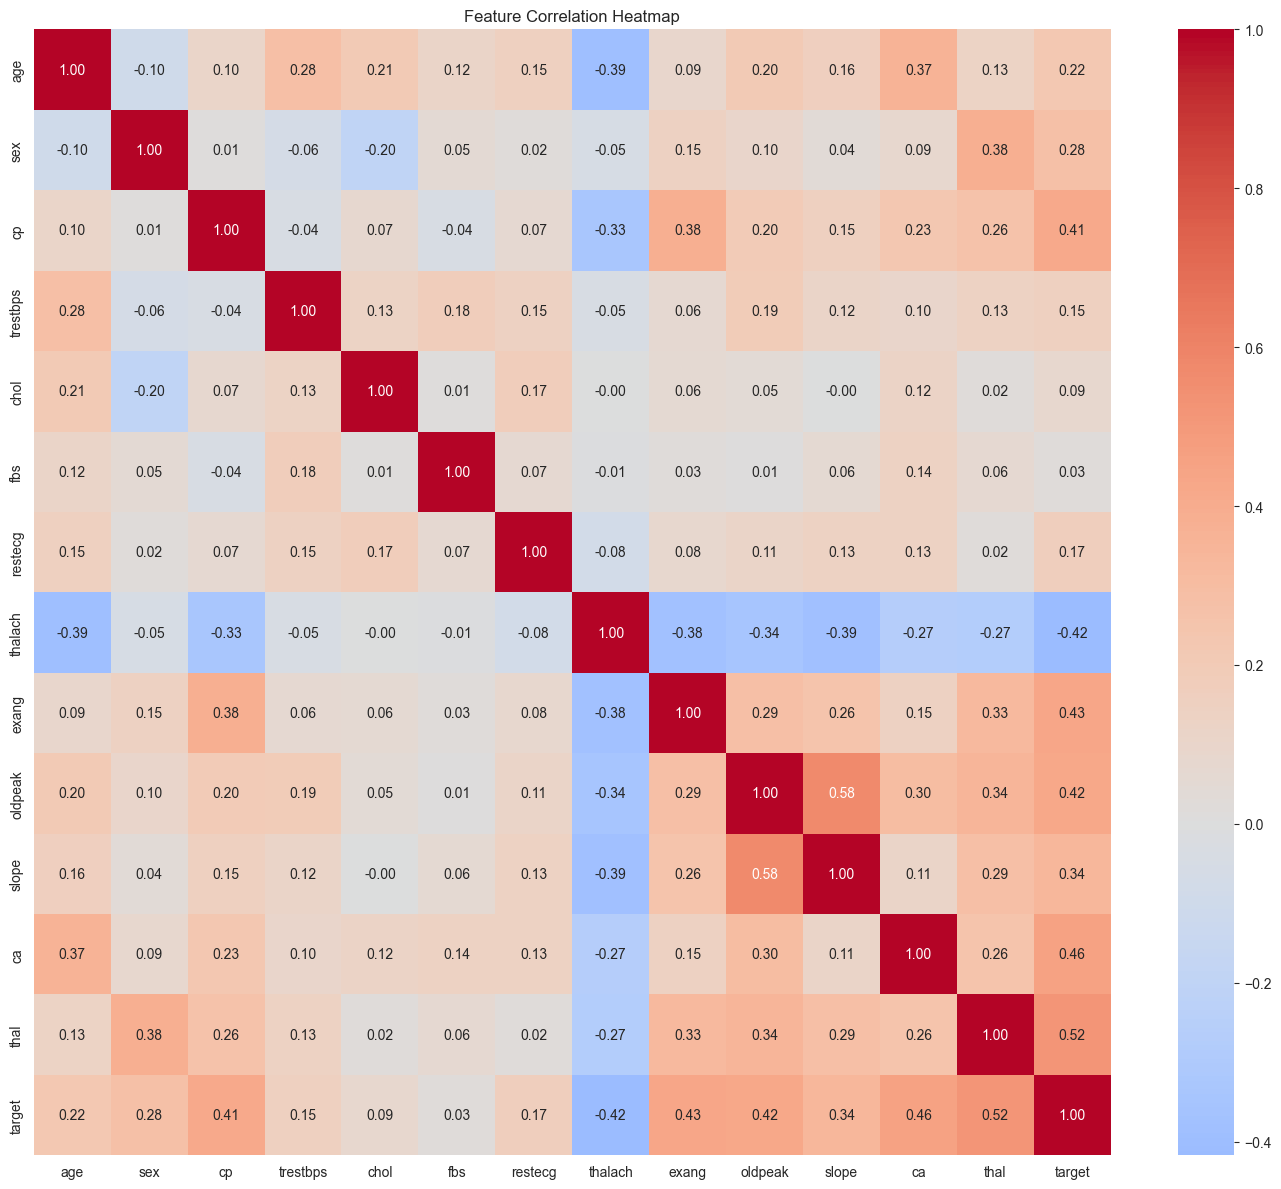

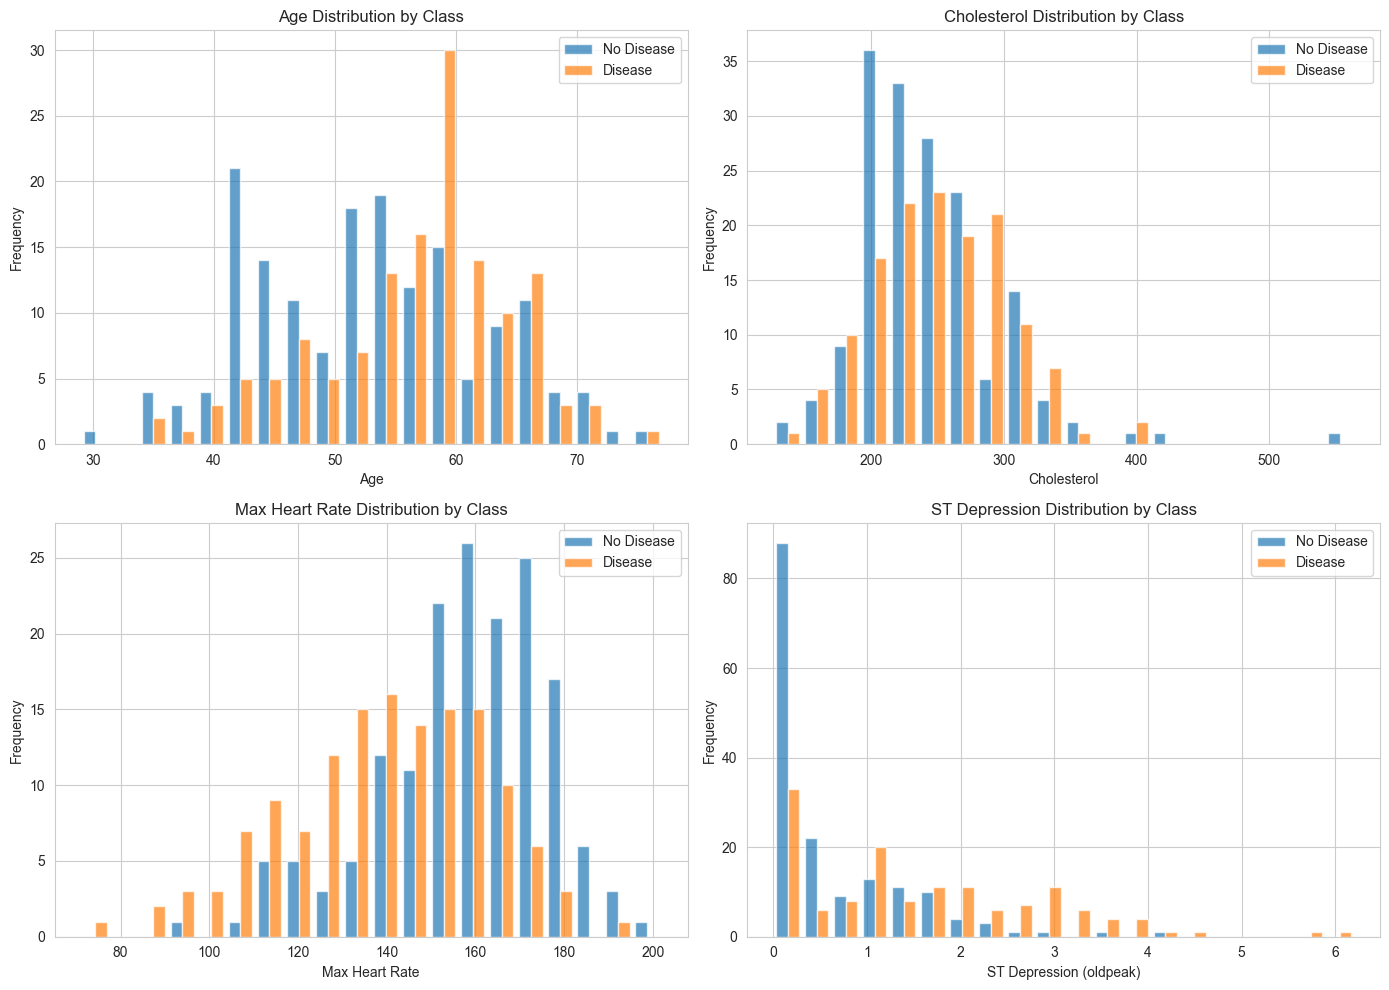

\n📊 Key Medical Observations:
- Patients with heart disease tend to have LOWER max heart rate (thalach)
- Patients with heart disease tend to have HIGHER ST depression (oldpeak)
- Age shows overlap but disease patients skew slightly older
- Cholesterol alone is not a strong discriminator


In [4]:

print('\\n' + '='*80)
print('SECTION 3: EXPLORATORY DATA ANALYSIS')
print('='*80)

# Plot class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=y)
plt.title('Class Distribution')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Disease', 'Disease'])
for i, count in enumerate(pd.Series(y).value_counts().sort_index()):
    plt.text(i, count + 5, str(count), ha='center')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

# Print class balance
class_counts = pd.Series(y).value_counts()
print(f'\\nClass Balance:')
print(f'No Disease (0): {class_counts[0]} ({class_counts[0]/len(y)*100:.1f}%)')
print(f'Disease (1): {class_counts[1]} ({class_counts[1]/len(y)*100:.1f}%)')

# Correlation heatmap
plt.figure(figsize=(14, 12))
X_with_target = X.copy()
X_with_target['target'] = y
correlation_matrix = X_with_target.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

# Plot distributions of key features split by class
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
axes[0, 0].hist([X[y==0]['age'], X[y==1]['age']], label=['No Disease', 'Disease'], bins=20, alpha=0.7)
axes[0, 0].set_title('Age Distribution by Class')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# Cholesterol distribution
axes[0, 1].hist([X[y==0]['chol'], X[y==1]['chol']], label=['No Disease', 'Disease'], bins=20, alpha=0.7)
axes[0, 1].set_title('Cholesterol Distribution by Class')
axes[0, 1].set_xlabel('Cholesterol')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Max Heart Rate distribution
axes[1, 0].hist([X[y==0]['thalach'], X[y==1]['thalach']], label=['No Disease', 'Disease'], bins=20, alpha=0.7)
axes[1, 0].set_title('Max Heart Rate Distribution by Class')
axes[1, 0].set_xlabel('Max Heart Rate')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# ST Depression distribution
axes[1, 1].hist([X[y==0]['oldpeak'], X[y==1]['oldpeak']], label=['No Disease', 'Disease'], bins=20, alpha=0.7)
axes[1, 1].set_title('ST Depression Distribution by Class')
axes[1, 1].set_xlabel('ST Depression (oldpeak)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

print('\\n📊 Key Medical Observations:')
print('- Patients with heart disease tend to have LOWER max heart rate (thalach)')
print('- Patients with heart disease tend to have HIGHER ST depression (oldpeak)')
print('- Age shows overlap but disease patients skew slightly older')
print('- Cholesterol alone is not a strong discriminator')


## SECTION 4: PREPROCESSING WITH SMOTEENN + FEATURE ENGINEERING

In [5]:
from imblearn.combine import SMOTEENN
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import warnings
warnings.filterwarnings('ignore')

CONTINUOUS_FEATURES = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
CATEGORICAL_FEATURES = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

feature_columns = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# FIX 5: Clinical risk score feature
# Weighted sum based on known clinical significance
def add_risk_score(df):
    df = df.copy()
    df['risk_score'] = (
        (df['thalach'] < 150).astype(float) * 1.5 +   # low max HR is a strong predictor
        (df['oldpeak'] > 1.0).astype(float) * 2.0 +   # ST depression = ischemia signal
        (df['cp'] == 4).astype(float) * 1.5 +          # asymptomatic chest pain = risky
        (df['ca'] > 0).astype(float) * 2.0 +           # blocked vessels
        (df['exang'] == 1).astype(float) * 1.0         # exercise-induced angina
    )
    return df

X_train = add_risk_score(X_train)
X_test  = add_risk_score(X_test)

# Update lists to include new feature
CONTINUOUS_FEATURES_EXT = CONTINUOUS_FEATURES + ['risk_score']
feature_columns_ext = list(X_train.columns)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[CONTINUOUS_FEATURES_EXT] = scaler.fit_transform(X_train[CONTINUOUS_FEATURES_EXT])
X_test_scaled[CONTINUOUS_FEATURES_EXT]  = scaler.transform(X_test[CONTINUOUS_FEATURES_EXT])

# FIX 6: SMOTEENN instead of plain SMOTE
# Oversamples minority class AND removes noisy borderline samples
smote_enn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train_scaled, y_train)

print('After SMOTEENN - class distribution:')
print(pd.Series(y_train_resampled).value_counts())


After SMOTEENN - class distribution:
1    79
0    74
Name: count, dtype: int64


## SECTION 5: TRAIN + CALIBRATE MODELS

In [6]:
from sklearn.base import BaseEstimator, ClassifierMixin

# Wrap XGBClassifier — BaseEstimator MUST come after ClassifierMixin in sklearn 1.6+
# so that __sklearn_tags__ is resolved correctly via the MRO.
class XGBClassifierWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self, n_estimators=100, random_state=42,
                 objective='binary:logistic', eval_metric='logloss', verbosity=0):
        self.n_estimators  = n_estimators
        self.random_state  = random_state
        self.objective     = objective
        self.eval_metric   = eval_metric
        self.verbosity     = verbosity

    def fit(self, X, y):
        self._xgb = XGBClassifier(
            n_estimators=self.n_estimators,
            random_state=self.random_state,
            objective=self.objective,
            eval_metric=self.eval_metric,
            verbosity=self.verbosity
        )
        self._xgb.fit(X, y)
        self.classes_ = self._xgb.classes_
        return self

    def predict(self, X):
        return self._xgb.predict(X)

    def predict_proba(self, X):
        return self._xgb.predict_proba(X)


base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifierWrapper(
                               n_estimators=100, random_state=42,
                               objective='binary:logistic',
                               eval_metric='logloss', verbosity=0
                           )
}

trained_models    = {}
calibrated_models = {}

for name, model in base_models.items():
    model.fit(X_train_resampled, y_train_resampled)
    trained_models[name] = model

    # FIX 1: Calibrate probabilities with isotonic regression
    cal_model = CalibratedClassifierCV(model, cv=5, method='isotonic')
    cal_model.fit(X_train_resampled, y_train_resampled)
    calibrated_models[name] = cal_model
    print(f'\u2713 {name} trained and calibrated')


✓ Logistic Regression trained and calibrated
✓ Random Forest trained and calibrated
✓ XGBoost trained and calibrated


## SECTION 6: EVALUATION WITH CALIBRATION PLOTS

              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC    Brier
Logistic Regression  0.852459   0.827586 0.857143  0.842105 0.919913 0.123784
      Random Forest  0.885246   0.888889 0.857143  0.872727 0.925866 0.104010
            XGBoost  0.868852   0.812500 0.928571  0.866667 0.936147 0.102929


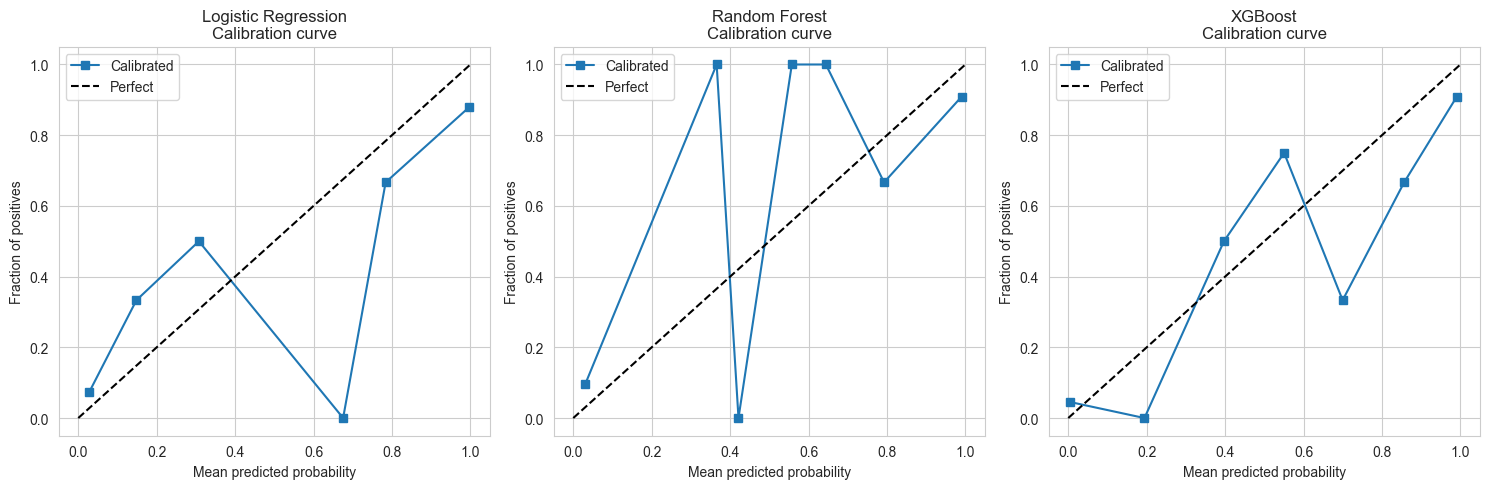


Best model: XGBoost


In [7]:
results = []

for name, model in calibrated_models.items():
    y_pred       = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_pred_proba),
        'Brier':     np.mean((y_pred_proba - y_test) ** 2)   # lower = better calibration
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Calibration curves
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, (name, model) in enumerate(calibrated_models.items()):
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    fraction_pos, mean_pred = calibration_curve(y_test, y_pred_proba, n_bins=8)
    axes[idx].plot(mean_pred, fraction_pos, 's-', label='Calibrated')
    axes[idx].plot([0, 1], [0, 1], 'k--', label='Perfect')
    axes[idx].set_title(f'{name}\nCalibration curve')
    axes[idx].set_xlabel('Mean predicted probability')
    axes[idx].set_ylabel('Fraction of positives')
    axes[idx].legend()
plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=100, bbox_inches='tight')
plt.show()

best_model_name = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
best_model      = calibrated_models[best_model_name]
print(f'\nBest model: {best_model_name}')


## SECTION 7: THREE-ZONE THRESHOLD SYSTEM

In [8]:
from sklearn.model_selection import StratifiedKFold

def find_thresholds_cv(model, X_tr, y_tr, min_precision=0.70):
    """
    Find lower and upper thresholds using cross-validation on training data.
    Avoids overfitting thresholds to the test set.
    Returns (low_threshold, high_threshold).
    """
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    low_thresholds, high_thresholds = [], []

    for fold_train_idx, fold_val_idx in skf.split(X_tr, y_tr):
        X_fold_tr  = X_tr.iloc[fold_train_idx]
        y_fold_tr  = y_tr[fold_train_idx]
        X_fold_val = X_tr.iloc[fold_val_idx]
        y_fold_val = y_tr[fold_val_idx]

        model.fit(X_fold_tr, y_fold_tr)
        proba = model.predict_proba(X_fold_val)[:, 1]

        prec, rec, thresh = precision_recall_curve(y_fold_val, proba)

        # High threshold: high precision (conservative)
        high_t = None
        for t, p in zip(thresh, prec[:-1]):
            if p >= 0.85:
                high_t = t
                break

        # Low threshold: high recall (sensitive)
        low_t = None
        for t, r in zip(thresh, rec[:-1]):
            if r >= 0.90:
                low_t = t
                break

        if high_t: high_thresholds.append(high_t)
        if low_t:  low_thresholds.append(low_t)

    low_final  = np.mean(low_thresholds)  if low_thresholds  else 0.30
    high_final = np.mean(high_thresholds) if high_thresholds else 0.65
    return low_final, high_final


# FIX 2 + 3: Three-zone prediction with CV-derived thresholds
LOW_THRESHOLD, HIGH_THRESHOLD = find_thresholds_cv(
    best_model, X_train_scaled, y_train
)
print(f'Low threshold (sensitive):     {LOW_THRESHOLD:.4f}')
print(f'High threshold (conservative): {HIGH_THRESHOLD:.4f}')
print(f'Uncertain zone: {LOW_THRESHOLD:.2f} - {HIGH_THRESHOLD:.2f}')


def predict_three_zone(proba, low_t, high_t):
    """
    Returns (prediction, zone) where zone is 'low_risk', 'uncertain', or 'high_risk'.
    Uncertain zone triggers clinical review rather than a hard binary call.
    """
    predictions, zones = [], []
    for p in proba:
        if p < low_t:
            predictions.append(0)
            zones.append('low_risk')
        elif p > high_t:
            predictions.append(1)
            zones.append('high_risk')
        else:
            predictions.append(-1)       # -1 = uncertain, needs follow-up
            zones.append('uncertain')
    return np.array(predictions), zones


y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred_zones, zone_labels = predict_three_zone(y_proba_best, LOW_THRESHOLD, HIGH_THRESHOLD)

zone_counts = pd.Series(zone_labels).value_counts()
print(f'\nZone distribution on test set:')
print(zone_counts)

# Evaluate only on definitive predictions (exclude uncertain zone)
definitive_mask = y_pred_zones != -1
y_definitive    = y_pred_zones[definitive_mask]
y_true_def      = y_test[definitive_mask]

print(f'\nPerformance on definitive predictions ({definitive_mask.sum()}/{len(y_test)} samples):')
print(f'  Accuracy:  {accuracy_score(y_true_def, y_definitive):.4f}')
print(f'  Precision: {precision_score(y_true_def, y_definitive):.4f}')
print(f'  Recall:    {recall_score(y_true_def, y_definitive):.4f}')
print(f'  F1-Score:  {f1_score(y_true_def, y_definitive):.4f}')
print(f'\n\u26a0\ufe0f  {(~definitive_mask).sum()} patients flagged as UNCERTAIN - recommend further clinical tests')


Low threshold (sensitive):     0.0131
High threshold (conservative): 0.6189
Uncertain zone: 0.01 - 0.62

Zone distribution on test set:
uncertain    32
high_risk    29
Name: count, dtype: int64

Performance on definitive predictions (29/61 samples):
  Accuracy:  0.8276
  Precision: 0.8276
  Recall:    1.0000
  F1-Score:  0.9057

⚠️  32 patients flagged as UNCERTAIN - recommend further clinical tests


## SECTION 7b: ENSEMBLE VOTING FOR UNCERTAIN CASES

In [9]:
# FIX 4: Use all 3 calibrated models for majority vote on uncertain cases
def ensemble_predict_uncertain(uncertain_indices, X_scaled, models_dict):
    """
    For each uncertain patient, get probability from all 3 models.
    Use soft voting (average probability) - more stable than hard majority vote.
    Also reports disagreement (std dev) as a confidence indicator.
    """
    proba_matrix = np.column_stack([
        m.predict_proba(X_scaled.iloc[uncertain_indices])[:, 1]
        for m in models_dict.values()
    ])
    ensemble_proba = proba_matrix.mean(axis=1)
    uncertainty    = proba_matrix.std(axis=1)   # high std = models disagree
    return ensemble_proba, uncertainty


uncertain_indices = np.where(y_pred_zones == -1)[0]

if len(uncertain_indices) > 0:
    ens_proba, ens_uncertainty = ensemble_predict_uncertain(
        uncertain_indices, X_test_scaled, calibrated_models
    )
    ens_pred = (ens_proba >= 0.50).astype(int)

    print(f'\nEnsemble resolution of {len(uncertain_indices)} uncertain cases:')
    for i, (idx, prob, unc, pred) in enumerate(
        zip(uncertain_indices, ens_proba, ens_uncertainty, ens_pred)
    ):
        true_label = y_test[idx]
        flag = '\u2713' if pred == true_label else '\u2717'
        print(f'  Sample {idx}: prob={prob:.3f} +/- {unc:.3f}  -> pred={pred}  true={true_label} {flag}')



Ensemble resolution of 32 uncertain cases:
  Sample 2: prob=0.022 +/- 0.016  -> pred=0  true=0 ✓
  Sample 3: prob=0.035 +/- 0.049  -> pred=0  true=0 ✓
  Sample 4: prob=0.376 +/- 0.227  -> pred=0  true=0 ✓
  Sample 5: prob=0.072 +/- 0.070  -> pred=0  true=0 ✓
  Sample 6: prob=0.146 +/- 0.172  -> pred=0  true=0 ✓
  Sample 7: prob=0.280 +/- 0.094  -> pred=0  true=0 ✓
  Sample 8: prob=0.469 +/- 0.264  -> pred=0  true=1 ✗
  Sample 9: prob=0.054 +/- 0.046  -> pred=0  true=0 ✓
  Sample 11: prob=0.109 +/- 0.154  -> pred=0  true=0 ✓
  Sample 12: prob=0.021 +/- 0.030  -> pred=0  true=0 ✓
  Sample 21: prob=0.087 +/- 0.123  -> pred=0  true=0 ✓
  Sample 23: prob=0.387 +/- 0.321  -> pred=0  true=0 ✓
  Sample 24: prob=0.456 +/- 0.161  -> pred=0  true=1 ✗
  Sample 25: prob=0.051 +/- 0.072  -> pred=0  true=0 ✓
  Sample 26: prob=0.049 +/- 0.039  -> pred=0  true=0 ✓
  Sample 28: prob=0.077 +/- 0.109  -> pred=0  true=0 ✓
  Sample 30: prob=0.187 +/- 0.160  -> pred=0  true=0 ✓
  Sample 33: prob=0.247 +/- 0

## SECTION 7c: CONFIDENCE + UNCERTAINTY REPORT

In [10]:
# FIX 7: Per-patient confidence report
def generate_patient_report(patient_idx, X_scaled, models_dict, low_t, high_t, feat_cols):
    proba_per_model = {
        name: m.predict_proba(X_scaled.iloc[[patient_idx]])[:, 1][0]
        for name, m in models_dict.items()
    }
    probas     = list(proba_per_model.values())
    mean_prob  = np.mean(probas)
    std_prob   = np.std(probas)
    brier      = np.mean([(p - y_test[patient_idx])**2 for p in probas])

    if mean_prob < low_t:
        zone, recommendation = 'LOW RISK', 'Routine monitoring'
    elif mean_prob > high_t:
        zone, recommendation = 'HIGH RISK', 'Immediate cardiology referral'
    else:
        zone, recommendation = 'UNCERTAIN', 'Further diagnostic tests recommended'

    print(f'\n{"="*50}')
    print(f'Patient {patient_idx} Report')
    print(f'{"="*50}')
    print(f'Mean probability:  {mean_prob:.3f}')
    print(f'Std dev (models):  {std_prob:.3f}  {"\u26a0\ufe0f high disagreement" if std_prob > 0.15 else "\u2713 models agree"}')
    print(f'Zone:              {zone}')
    print(f'Recommendation:    {recommendation}')
    print(f'Model breakdown:')
    for name, p in proba_per_model.items():
        print(f'  {name:20s}: {p:.3f}')
    return mean_prob, zone


# Generate report for first 5 test patients
for i in range(min(5, len(X_test_scaled))):
    generate_patient_report(i, X_test_scaled, calibrated_models,
                            LOW_THRESHOLD, HIGH_THRESHOLD, feature_columns_ext)



Patient 0 Report
Mean probability:  0.245
Std dev (models):  0.312  ⚠️ high disagreement
Zone:              UNCERTAIN
Recommendation:    Further diagnostic tests recommended
Model breakdown:
  Logistic Regression : 0.049
  Random Forest       : 0.000
  XGBoost             : 0.686

Patient 1 Report
Mean probability:  0.899
Std dev (models):  0.093  ✓ models agree
Zone:              HIGH RISK
Recommendation:    Immediate cardiology referral
Model breakdown:
  Logistic Regression : 0.986
  Random Forest       : 0.940
  XGBoost             : 0.771

Patient 2 Report
Mean probability:  0.022
Std dev (models):  0.016  ✓ models agree
Zone:              UNCERTAIN
Recommendation:    Further diagnostic tests recommended
Model breakdown:
  Logistic Regression : 0.028
  Random Forest       : 0.000
  XGBoost             : 0.039

Patient 3 Report
Mean probability:  0.035
Std dev (models):  0.049  ✓ models agree
Zone:              UNCERTAIN
Recommendation:    Further diagnostic tests recommended
Mode

## SECTION 8: SHAP EXPLAINABILITY


SECTION 8: SHAP EXPLAINABILITY


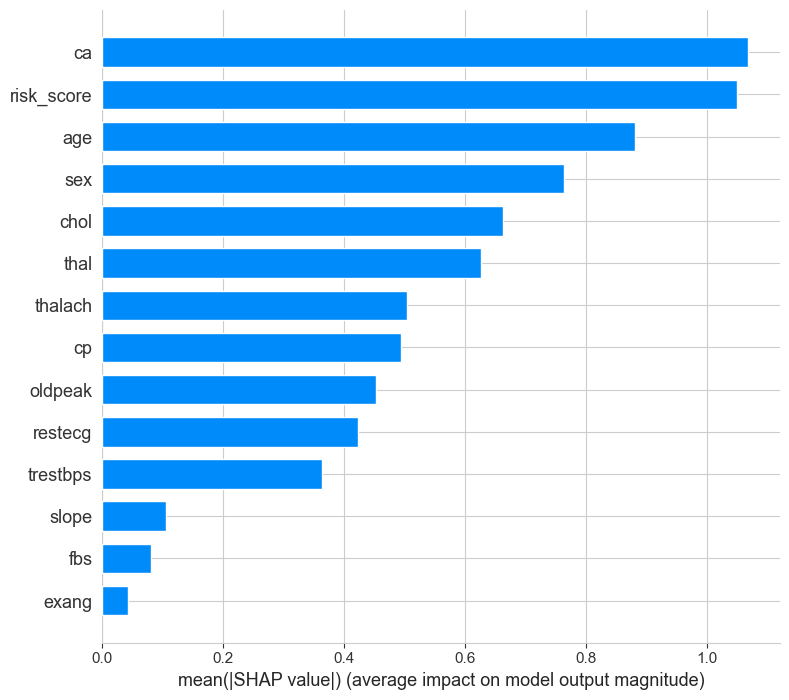

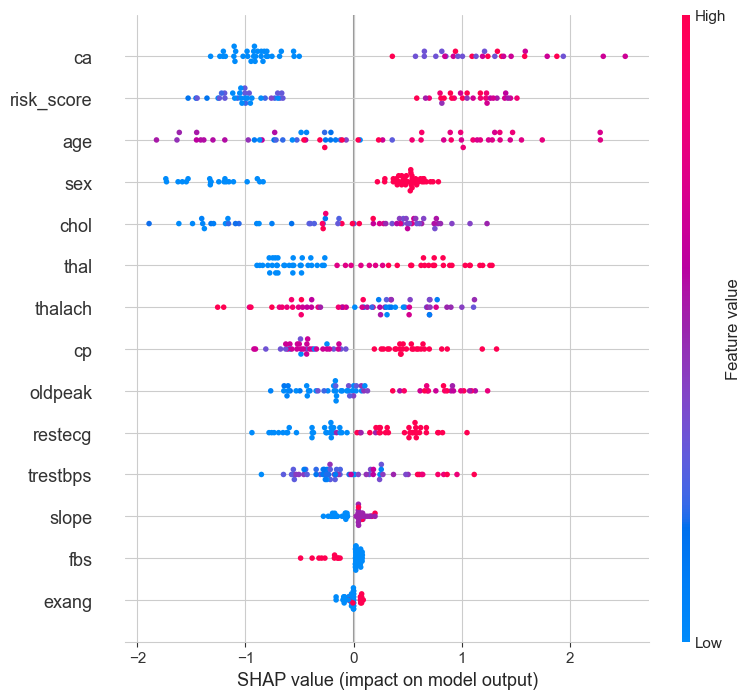

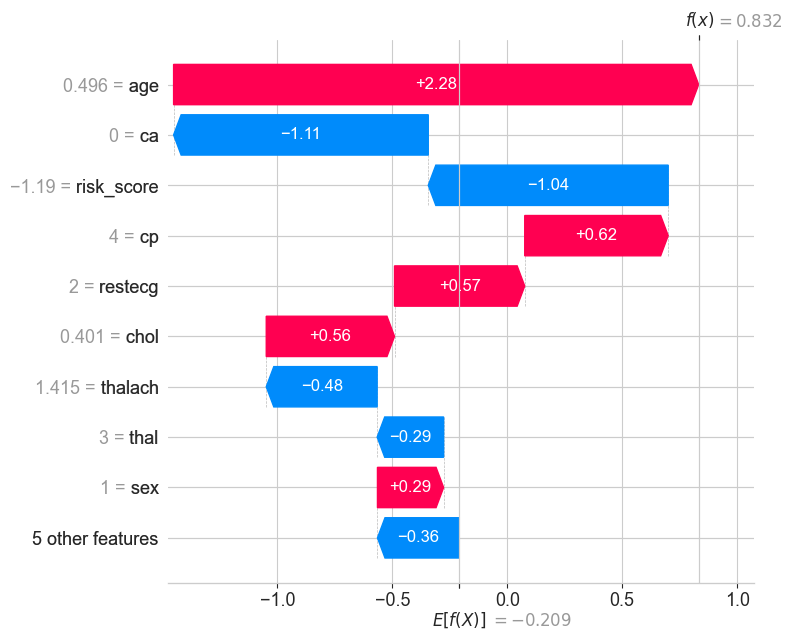

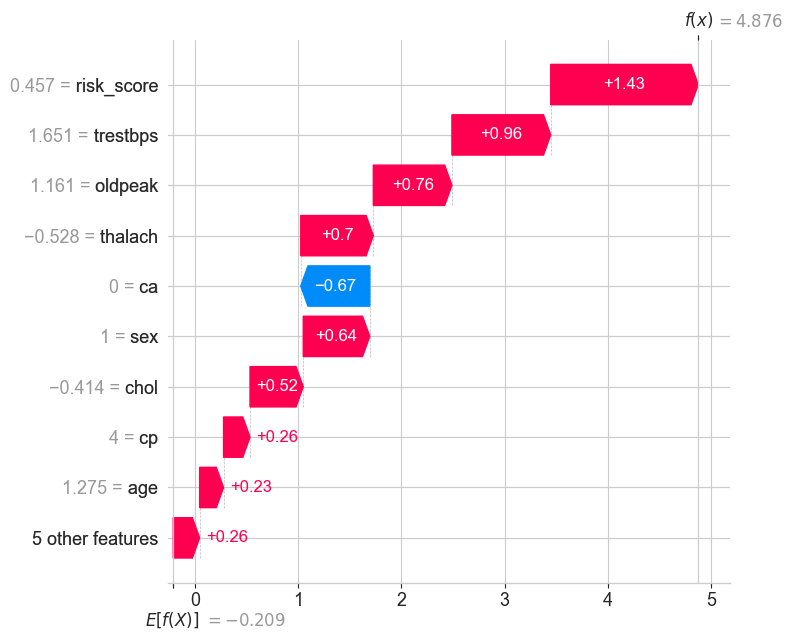

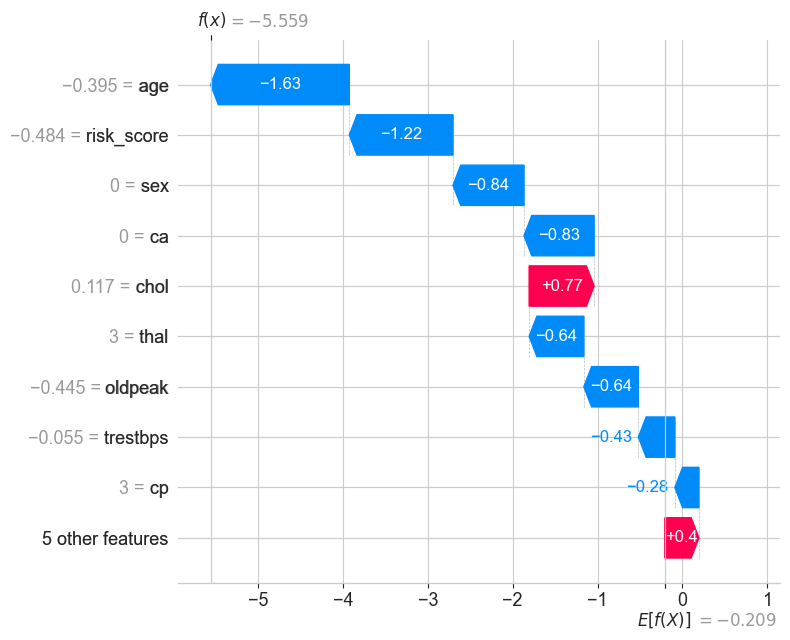

✓ SHAP explainability plots saved


In [11]:
print('\n' + '='*80)
print('SECTION 8: SHAP EXPLAINABILITY')
print('='*80)

# Select appropriate SHAP explainer based on best model type
if best_model_name == 'XGBoost':
    # Unwrap: CalibratedClassifierCV -> XGBClassifierWrapper -> native XGBClassifier
    underlying = best_model.calibrated_classifiers_[0].estimator._xgb
    explainer = shap.TreeExplainer(underlying)
    shap_values = explainer.shap_values(X_test_scaled)
elif best_model_name == 'Random Forest':
    underlying = best_model.calibrated_classifiers_[0].estimator
    explainer = shap.TreeExplainer(underlying)
    shap_values = explainer.shap_values(X_test_scaled)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
else:
    # Logistic Regression - use LinearExplainer
    underlying = best_model.calibrated_classifiers_[0].estimator
    explainer = shap.LinearExplainer(underlying, X_train_resampled)
    shap_values = explainer.shap_values(X_test_scaled)

feature_names = feature_columns_ext

# Summary bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names,
                  plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=100, bbox_inches='tight')
plt.show()

# Beeswarm plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=100, bbox_inches='tight')
plt.show()

# Waterfall plots for first 3 test samples
for i in range(min(3, len(X_test_scaled))):
    shap_exp = shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, list)
                    else explainer.expected_value[1],
        data=X_test_scaled.iloc[i].values,
        feature_names=feature_names
    )
    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(shap_exp, show=False)
    plt.tight_layout()
    plt.savefig(f'shap_waterfall_sample_{i+1}.png', dpi=100, bbox_inches='tight')
    plt.show()

print('\u2713 SHAP explainability plots saved')


## SECTION 9: SAVE ARTIFACTS

In [12]:
print('\n' + '='*80)
print('SECTION 9: SAVE ARTIFACTS')
print('='*80)

joblib.dump(best_model,          '../backend/model.joblib')
joblib.dump(calibrated_models,   '../backend/calibrated_models.joblib')
joblib.dump(scaler,              '../backend/scaler.joblib')
joblib.dump(LOW_THRESHOLD,       '../backend/threshold_low.joblib')
joblib.dump(HIGH_THRESHOLD,      '../backend/threshold_high.joblib')
joblib.dump(feature_columns_ext, '../backend/feature_columns.joblib')
joblib.dump(X_train_resampled,   '../backend/X_train_background.joblib')
print('\u2713 All artifacts saved')



SECTION 9: SAVE ARTIFACTS
✓ All artifacts saved
